## Meta Platforms Inc. (FB) — Sentiment Analysis & Correlation

### Overview
This notebook quantifies the relationship between financial news sentiment
and daily FB stock price returns. We apply VADER sentiment analysis to
news headlines, compute daily stock returns, and measure the statistical
correlation between the two using Pearson, Spearman and Kendall methods.

### Objectives
- Compare TextBlob vs VADER for financial headline sentiment analysis
- Align news publication dates to FB trading days
- Score each headline using VADER sentiment analysis
- Aggregate daily sentiment scores
- Compute daily stock returns
- Measure correlation between sentiment and returns
- Visualize and interpret the relationship



**We use VADER** because financial headlines are short, punchy, and often
use capitalization and punctuation for emphasis — exactly the context VADER
was designed for. TextBlob tends to classify too many financial headlines
as neutral, reducing sensitivity to meaningful sentiment shifts.

In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('vader_lexicon', quiet=True)

from src.data_loader import load_news_data, filter_by_stock, load_stock_data
from src.sentiment_analyzer import (
    score_headlines_vader,
    score_headlines_textblob,
    classify_sentiment,
    align_dates,
    aggregate_daily_sentiment,
    compute_daily_returns,
    merge_sentiment_returns,
    compute_correlation
)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'serif'

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load Data

We load both the financial news dataset and FB stock price data
using our modular data loading functions from src/data_loader.py.

In [3]:
# Load news data
df_news = load_news_data('../data/raw/raw_analyst_ratings.csv')

# Filter for FB
fb_news = filter_by_stock(df_news, 'FB')

# Load stock price data
fb_stock = load_stock_data('../data/raw/META.csv')

print(f"\nNews articles  : {len(fb_news)}")
print(f"Stock records  : {len(fb_stock)}")
print(f"\nNews date range  : {fb_news['date'].min().date()} to {fb_news['date'].max().date()}")
print(f"Stock date range : {fb_stock['Date'].min().date()} to {fb_stock['Date'].max().date()}")

✅ Loaded 1407328 news articles.
✅ Found 380 articles for FB.
✅ Loaded 2923 rows. No missing values.

News articles  : 380
Stock records  : 2923

News date range  : 2020-02-19 to 2020-06-10
Stock date range : 2012-05-18 to 2023-12-29


## 3. TextBlob vs VADER Comparison

Before proceeding with our main analysis, we demonstrate the difference
between TextBlob and VADER on a sample of real FB headlines to justify
our tool selection.

In [4]:
# Sample 10 headlines for comparison
sample_headlines = fb_news['headline'].sample(10, random_state=42).tolist()

# Score with both tools
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

sia = SentimentIntensityAnalyzer()
comparison = []

for h in sample_headlines:
    vader_compound = sia.polarity_scores(h)['compound']
    tb_polarity = TextBlob(h).sentiment.polarity

    vader_label = classify_sentiment(vader_compound)
    tb_label = ('Positive' if tb_polarity > 0.1
                else 'Negative' if tb_polarity < -0.1
                else 'Neutral')

    comparison.append({
        'headline': h[:60] + '...' if len(h) > 60 else h,
        'vader_compound': round(vader_compound, 3),
        'vader_label': vader_label,
        'tb_polarity': round(tb_polarity, 3),
        'tb_label': tb_label,
        'agreement': '✅' if vader_label == tb_label else '❌'
    })

comp_df = pd.DataFrame(comparison)
print("=== TextBlob vs VADER Comparison ===")
print(comp_df.to_string(index=False))
print(f"\nAgreement rate: {(comp_df['agreement'] == '✅').sum()}/10")

=== TextBlob vs VADER Comparison ===
                                                       headline  vader_compound vader_label  tb_polarity tb_label agreement
Morgan Stanley Maintains Overweight on Facebook, Lowers Pric...          -0.459    Negative        0.000  Neutral         ❌
Hearing Some Users Reporting Facebook's WhatsApp, Instagram ...           0.000     Neutral       -0.156 Negative         ❌
      Ad Sales Decrease With Covid-19 But Digital Holds The Key           0.000     Neutral        0.000  Neutral         ✅
Trump's Executive Order To Expose Social Media To Lawsuits O...          -0.296    Negative        0.033  Neutral         ❌
Zuckerberg Says Facebook Policies Allow For Stronger Free Ex...           0.778    Positive        0.400 Positive         ✅
Tech Stocks In Correction Territory, Including Apple And Fac...           0.000     Neutral        0.000  Neutral         ✅
Facebook's Internal Research Showed Its Algorithms Were Caus...          -0.649    Negative    

## 4. Date Alignment

We normalize news publication timestamps to UTC and align them to
the nearest FB trading day. Articles published on weekends or
market holidays are mapped to the next available trading day.
This ensures every news article is matched to a valid stock return.

In [5]:
# Align news dates to trading days
fb_news_aligned = align_dates(fb_news, fb_stock)

print(f"Total articles after alignment : {len(fb_news_aligned)}")

# Check for unmatched articles
unmatched = fb_news_aligned['trading_date'].isna().sum()
print(f"Unmatched articles             : {unmatched}")

print(f"\nSample of aligned dates:")
print(fb_news_aligned[
    ['date', 'date_only', 'trading_date', 'headline']
].head(10).to_string(index=False))

Total articles after alignment : 380
Unmatched articles             : 0

Sample of aligned dates:
                     date  date_only trading_date                                                                                                                 headline
2020-06-10 20:20:19+00:00 2020-06-10   2020-06-10                                              As Expected: Fed Keeps Rates Unchanged and Forecasts Years Of Dovish Policy
2020-06-10 19:25:13+00:00 2020-06-10   2020-06-10                                                Facebook, Snap Analyst Projects Q2 Revenue Upside For Social Media Stocks
2020-06-10 15:33:26+00:00 2020-06-10   2020-06-10                                                    Tech Stocks And FAANGS Strong Again To Start Day As Market Awaits Fed
2020-06-10 04:52:01+00:00 2020-06-10   2020-06-10                                                                  Big Tech Reaches New Record Heights At The Stock Market
2020-06-10 04:28:00+00:00 2020-06-10   2020-06-

## 5. Sentiment Scoring with VADER

We apply VADER SentimentIntensityAnalyzer to each headline to compute
a compound sentiment score ranging from -1 (most negative) to +1 (most
positive). Each article is then classified as:
- **Positive** — compound score >= 0.05
- **Neutral**  — compound score between -0.05 and 0.05
- **Negative** — compound score <= -0.05

In [6]:
# Score headlines with VADER
fb_news_scored = score_headlines_vader(fb_news_aligned)

# Add sentiment label
fb_news_scored['sentiment_label'] = fb_news_scored['compound'].apply(
    classify_sentiment)

print("=== VADER Sentiment Score Statistics ===")
print(fb_news_scored['compound'].describe())
print(f"\nSentiment Distribution:")
print(fb_news_scored['sentiment_label'].value_counts())

fb_news_scored[['headline', 'compound',
                   'sentiment_label']].head(10)

=== VADER Sentiment Score Statistics ===
count    380.000000
mean       0.070959
std        0.311483
min       -0.840200
25%        0.000000
50%        0.000000
75%        0.272000
max        0.918600
Name: compound, dtype: float64

Sentiment Distribution:
sentiment_label
Neutral     192
Positive    119
Negative     69
Name: count, dtype: int64


,headline,compound,sentiment_label
0,As Expected: Fed Keeps Rates Unchanged and For...,0.0000,Neutral
1,"Facebook, Snap Analyst Projects Q2 Revenue Ups...",0.0000,Neutral
2,Tech Stocks And FAANGS Strong Again To Start D...,0.5574,Positive
3,Big Tech Reaches New Record Heights At The Sto...,0.0516,Positive
4,"Twitter, Square Will Mark Juneteenth As Holida...",0.7096,Positive
5,Afternoon Market Stats in 5 Minutes,0.0000,Neutral
6,Facebook shares are trading higher despite mar...,0.5472,Positive
7,IRS Alerts Against Criminals Profiteering From...,-0.8402,Negative
8,Morning Market Stats in 5 Minutes,0.0000,Neutral
9,Facebook-Backed Jio Platforms Gets $750M From ...,0.2500,Positive


### 5.1 Sentiment Distribution Visualization

The charts below show the distribution of compound sentiment scores
and the breakdown of positive, neutral and negative articles.

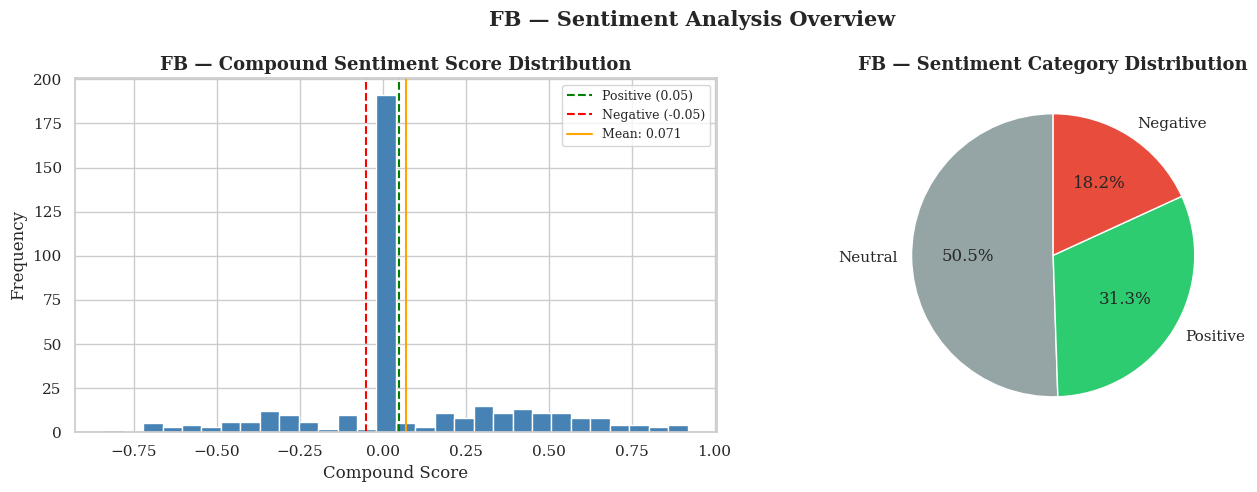

✅ Sentiment distribution plot rendered!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(fb_news_scored['compound'], bins=30,
             color='steelblue', edgecolor='white')
axes[0].axvline(0.05,  color='green', linestyle='--',
                label='Positive (0.05)')
axes[0].axvline(-0.05, color='red',   linestyle='--',
                label='Negative (-0.05)')
axes[0].axvline(fb_news_scored['compound'].mean(),
                color='orange', linestyle='-',
                label=f"Mean: {fb_news_scored['compound'].mean():.3f}")
axes[0].set_title('FB — Compound Sentiment Score Distribution',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Compound Score')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# Pie chart
sentiment_counts = fb_news_scored['sentiment_label'].value_counts()
colors_pie = {'Positive': '#2ecc71',
              'Neutral':  '#95a5a6',
              'Negative': '#e74c3c'}
axes[1].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    colors=[colors_pie[s] for s in sentiment_counts.index],
    autopct='%1.1f%%', startangle=90)
axes[1].set_title('FB — Sentiment Category Distribution',
                  fontsize=13, fontweight='bold')

plt.suptitle('FB — Sentiment Analysis Overview',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Sentiment distribution plot rendered!")

## 6. Daily Sentiment Aggregation

When multiple articles are published on the same trading day, we
compute the average compound score to produce a single daily
sentiment value per stock.

In [8]:
# Aggregate to daily sentiment
daily_sentiment = aggregate_daily_sentiment(fb_news_scored)

print(f"Total trading days with news: {len(daily_sentiment)}")
print(f"\nDaily Sentiment Summary:")
print(daily_sentiment['compound'].describe())
print(f"\nDaily Sentiment Labels:")
print(daily_sentiment['sentiment_label'].value_counts())
daily_sentiment.head(10)

Total trading days with news: 74

Daily Sentiment Summary:
count    74.000000
mean      0.067776
std       0.183900
min      -0.281750
25%      -0.047087
50%       0.042747
75%       0.194344
max       0.568500
Name: compound, dtype: float64

Daily Sentiment Labels:
sentiment_label
Positive    33
Neutral     22
Negative    19
Name: count, dtype: int64


,trading_date,compound,article_count,sentiment_label
0,2020-02-19,0.190900,2,Positive
1,2020-02-20,0.328600,2,Positive
2,2020-02-21,0.021000,4,Neutral
3,2020-02-24,0.041460,5,Neutral
4,2020-02-25,0.223433,3,Positive
5,2020-02-26,0.000000,2,Neutral
6,2020-02-27,-0.166500,3,Negative
7,2020-02-28,0.044033,6,Neutral
8,2020-03-02,0.194250,4,Positive
9,2020-03-03,0.000000,1,Neutral


## 7. Daily Stock Returns

We compute the daily percentage change in FB closing prices
using the formula:

**Daily Return = (Close_t - Close_t-1) / Close_t-1 × 100**

In [9]:
# Compute daily returns
daily_returns = compute_daily_returns(fb_stock)

print(f"Total trading days with returns: {len(daily_returns)}")
print(f"\nDaily Returns Summary:")
print(daily_returns['daily_return'].describe())
daily_returns.head(10)

Total trading days with returns: 2922

Daily Returns Summary:
count    2922.000000
mean        0.108187
std         2.527991
min       -26.390092
25%        -1.004540
50%         0.099839
75%         1.282529
max        29.611487
Name: daily_return, dtype: float64


,Date,Close,daily_return
1,2012-05-21,33.821495,-10.986138
2,2012-05-22,30.810066,-8.903890
3,2012-05-23,31.803938,3.225802
4,2012-05-24,32.827625,3.218744
5,2012-05-25,31.714489,-3.390852
6,2012-05-29,28.663300,-9.620806
7,2012-05-30,28.017281,-2.253819
8,2012-05-31,29.418642,5.001775
9,2012-06-01,27.550161,-6.351349
10,2012-06-04,26.735184,-2.958159


## 8. Merge Sentiment & Returns

We merge the daily sentiment scores with the daily stock returns
on the aligned trading date.

In [10]:
# Merge
merged_df = merge_sentiment_returns(daily_sentiment, daily_returns)

print(f"Total matched trading days : {len(merged_df)}")
print(f"From : {merged_df['trading_date'].min().date()}")
print(f"To   : {merged_df['trading_date'].max().date()}")
merged_df[['trading_date', 'compound', 'sentiment_label',
           'article_count', 'daily_return']].head(10)

Total matched trading days : 74
From : 2020-02-19
To   : 2020-06-10


,trading_date,compound,sentiment_label,article_count,daily_return
0,2020-02-19,0.190900,Positive,2,-0.142342
1,2020-02-20,0.328600,Positive,2,-1.337998
2,2020-02-21,0.021000,Neutral,4,-2.050520
3,2020-02-24,0.041460,Neutral,5,-4.500897
4,2020-02-25,0.223433,Positive,3,-1.967907
5,2020-02-26,0.000000,Neutral,2,0.218515
6,2020-02-27,-0.166500,Negative,3,-3.777892
7,2020-02-28,0.044033,Neutral,6,1.433459
8,2020-03-02,0.194250,Positive,4,2.062661
9,2020-03-03,0.000000,Neutral,1,-5.370585


## 9. Correlation Analysis

We compute three types of correlation coefficients between daily
sentiment scores and daily stock returns:

| Method | Best For | Outlier Sensitivity |
|--------|---------|-------------------|
| **Pearson** | Linear, normally distributed data | High |
| **Spearman** | Monotonic, non-linear data | Robust |
| **Kendall** | Small datasets, ordinal data | Most robust |

**Null Hypothesis (H₀):** There is no correlation between news sentiment
and daily stock returns.

**P-Value < 0.05:** We reject H₀ — the correlation is statistically significant.
**P-Value > 0.05:** We fail to reject H₀ — the correlation may be random noise.

In [11]:
# Compute all three correlations
corr_results = compute_correlation(merged_df)

print("=== FB Correlation Results ===\n")
for method, result in corr_results.items():
    sig = 'Yes ✅' if result['p'] < 0.05 else 'No ❌'
    print(f"{method.capitalize():10} | r = {result['r']:+.4f} | "
          f"p = {result['p']:.4f} | Significant: {sig}")

# Use Pearson as primary
corr = corr_results['pearson']['r']
pval = corr_results['pearson']['p']

if   abs(corr) < 0.2: strength = "Very Weak"
elif abs(corr) < 0.4: strength = "Weak"
elif abs(corr) < 0.6: strength = "Moderate"
elif abs(corr) < 0.8: strength = "Strong"
else:                  strength = "Very Strong"

direction = "Positive" if corr > 0 else "Negative"
print(f"\nPrimary (Pearson): {strength} {direction} correlation")

=== FB Correlation Results ===

Pearson    | r = +0.4503 | p = 0.0001 | Significant: Yes ✅
Spearman   | r = +0.4577 | p = 0.0000 | Significant: Yes ✅
Kendall    | r = +0.3246 | p = 0.0000 | Significant: Yes ✅

Primary (Pearson): Moderate Positive correlation


### 9.1 Correlation Heatmap

The heatmap below shows the Pearson correlation matrix between
daily sentiment scores and daily stock returns.

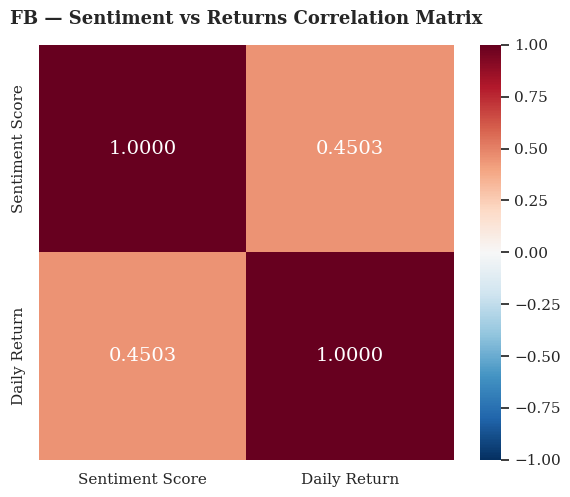

✅ Correlation heatmap rendered!


In [12]:
# Correlation heatmap
corr_matrix = merged_df[['compound', 'daily_return']].corr(
    method='pearson')
corr_matrix.index   = ['Sentiment Score', 'Daily Return']
corr_matrix.columns = ['Sentiment Score', 'Daily Return']

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r',
            vmin=-1, vmax=1, square=True, fmt='.4f',
            annot_kws={"size": 14})
plt.title('FB — Sentiment vs Returns Correlation Matrix',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print("✅ Correlation heatmap rendered!")

### 9.2 Scatter Plot — Sentiment vs Returns

The scatter plot below shows the relationship between daily sentiment
scores and daily stock returns, annotated with the Pearson correlation
coefficient and a regression line.

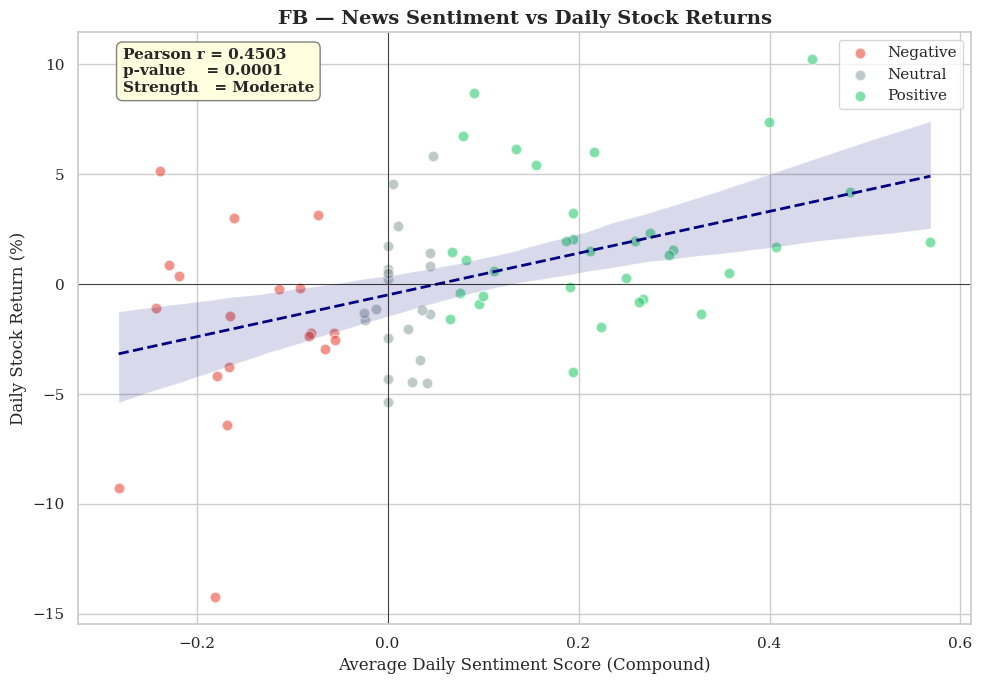

✅ Scatter plot rendered!


In [13]:
fig, ax = plt.subplots(figsize=(10, 7))

colors_map = {'Positive': '#2ecc71',
              'Neutral':  '#95a5a6',
              'Negative': '#e74c3c'}

for label, group in merged_df.groupby('sentiment_label'):
    ax.scatter(group['compound'], group['daily_return'],
               c=colors_map[label], label=label,
               alpha=0.6, s=60, edgecolors='white')

# Regression line
sns.regplot(x='compound', y='daily_return', data=merged_df,
            scatter=False, ax=ax, color='navy',
            line_kws={'linewidth': 2, 'linestyle': '--'})

# Annotate
ax.annotate(
    f'Pearson r = {corr:.4f}\np-value    = {pval:.4f}\n'
    f'Strength   = {strength}',
    xy=(0.05, 0.90), xycoords='axes fraction',
    fontsize=11, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='lightyellow', edgecolor='gray'))

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('FB — News Sentiment vs Daily Stock Returns',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Average Daily Sentiment Score (Compound)',
              fontsize=12)
ax.set_ylabel('Daily Stock Return (%)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Scatter plot rendered!")

### 9.3 Average Daily Return by Sentiment Category

The bar chart below shows the average daily stock return for each
sentiment category, revealing whether positive news days are
associated with higher returns.

=== Average Daily Return by Sentiment Category ===
sentiment_label  avg_return  count      std
       Negative   -2.135071     19 4.442504
        Neutral   -0.647310     22 2.914089
       Positive    2.001580     33 3.264812


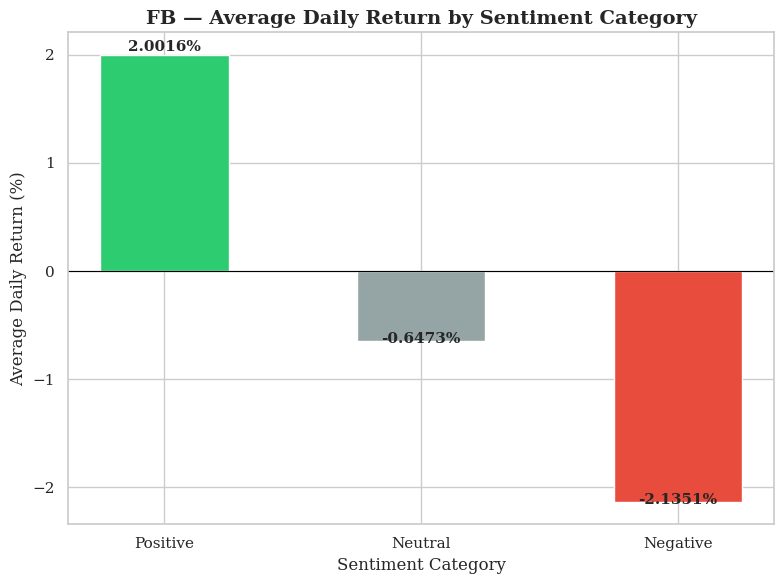

✅ Bar chart rendered!


In [14]:
# Average return per sentiment category
category_returns = merged_df.groupby(
    'sentiment_label')['daily_return'].agg(
    ['mean', 'count', 'std']).reset_index()
category_returns.columns = ['sentiment_label', 'avg_return',
                             'count', 'std']

print("=== Average Daily Return by Sentiment Category ===")
print(category_returns.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))

colors_bar = {'Positive': '#2ecc71',
              'Neutral':  '#95a5a6',
              'Negative': '#e74c3c'}

# Ensure consistent order
order = ['Positive', 'Neutral', 'Negative']
cat_ordered = category_returns.set_index(
    'sentiment_label').reindex(order).reset_index()
cat_ordered = cat_ordered.dropna()

bars = ax.bar(
    cat_ordered['sentiment_label'],
    cat_ordered['avg_return'],
    color=[colors_bar[s] for s in cat_ordered['sentiment_label']],
    edgecolor='white', width=0.5)

for bar, val in zip(bars, cat_ordered['avg_return']):
    offset = 0.01 if val >= 0 else -0.05
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + offset,
            f'{val:.4f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('FB — Average Daily Return by Sentiment Category',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment Category', fontsize=12)
ax.set_ylabel('Average Daily Return (%)', fontsize=12)
plt.tight_layout()
plt.show()
print("✅ Bar chart rendered!")

### 9.4 Sentiment Score & Stock Return Over Time

The time series chart shows how daily sentiment scores and daily
stock returns move together over the analysis period.

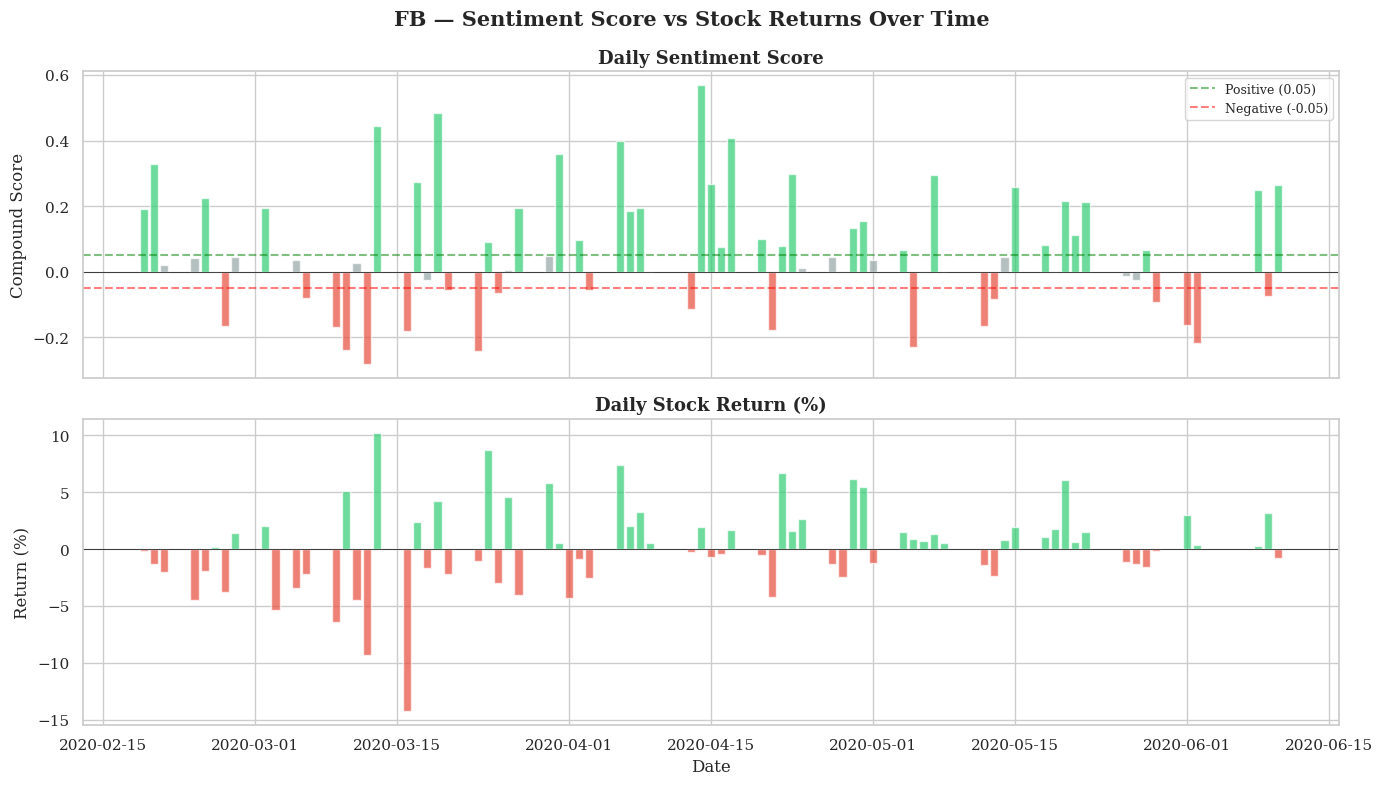

✅ Time series plot rendered!


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Sentiment over time
axes[0].bar(merged_df['trading_date'], merged_df['compound'],
            color=['#2ecc71' if v >= 0.05
                   else '#e74c3c' if v <= -0.05
                   else '#95a5a6'
                   for v in merged_df['compound']],
            alpha=0.7)
axes[0].axhline(0.05,  color='green', linestyle='--',
                alpha=0.5, label='Positive (0.05)')
axes[0].axhline(-0.05, color='red',   linestyle='--',
                alpha=0.5, label='Negative (-0.05)')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Daily Sentiment Score',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Compound Score')
axes[0].legend(fontsize=9)

# Returns over time
axes[1].bar(merged_df['trading_date'], merged_df['daily_return'],
            color=['#2ecc71' if v >= 0 else '#e74c3c'
                   for v in merged_df['daily_return']],
            alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Daily Stock Return (%)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Return (%)')
axes[1].set_xlabel('Date')

plt.suptitle('FB — Sentiment Score vs Stock Returns Over Time',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Time series plot rendered!")

## 10. Key Findings & Summary

In [16]:
print("=" * 55)
print("   FB SENTIMENT CORRELATION — KEY FINDINGS")
print("=" * 55)

print(f"""
📰 ANALYSIS OVERVIEW
- Total articles analyzed     : {len(fb_news_scored)}
- Trading days matched        : {len(merged_df)}
- Date range                  : {merged_df['trading_date'].min().date()} to {merged_df['trading_date'].max().date()}

😊 SENTIMENT SUMMARY
- Average compound score      : {fb_news_scored['compound'].mean():.4f}
- Positive articles           : {(fb_news_scored['sentiment_label'] == 'Positive').sum()}
- Neutral articles            : {(fb_news_scored['sentiment_label'] == 'Neutral').sum()}
- Negative articles           : {(fb_news_scored['sentiment_label'] == 'Negative').sum()}

📈 CORRELATION RESULTS
- Pearson  r = {corr_results['pearson']['r']:+.4f}  p = {corr_results['pearson']['p']:.4f}  {'✅ Significant' if corr_results['pearson']['p'] < 0.05 else '❌ Not Significant'}
- Spearman r = {corr_results['spearman']['r']:+.4f}  p = {corr_results['spearman']['p']:.4f}  {'✅ Significant' if corr_results['spearman']['p'] < 0.05 else '❌ Not Significant'}
- Kendall  r = {corr_results['kendall']['r']:+.4f}  p = {corr_results['kendall']['p']:.4f}  {'✅ Significant' if corr_results['kendall']['p'] < 0.05 else '❌ Not Significant'}

- Pearson Strength            : {strength}
- Pearson Direction           : {direction}

📊 AVERAGE RETURNS BY SENTIMENT
""")
for _, row in cat_ordered.iterrows():
    print(f"  {row['sentiment_label']:10} : {row['avg_return']:.4f}% "
          f"(n={int(row['count'])})")

print("\n" + "=" * 55)

   FB SENTIMENT CORRELATION — KEY FINDINGS

📰 ANALYSIS OVERVIEW
- Total articles analyzed     : 380
- Trading days matched        : 74
- Date range                  : 2020-02-19 to 2020-06-10

😊 SENTIMENT SUMMARY
- Average compound score      : 0.0710
- Positive articles           : 119
- Neutral articles            : 192
- Negative articles           : 69

📈 CORRELATION RESULTS
- Pearson  r = +0.4503  p = 0.0001  ✅ Significant
- Spearman r = +0.4577  p = 0.0000  ✅ Significant
- Kendall  r = +0.3246  p = 0.0000  ✅ Significant

- Pearson Strength            : Moderate
- Pearson Direction           : Positive

📊 AVERAGE RETURNS BY SENTIMENT

  Positive   : 2.0016% (n=33)
  Neutral    : -0.6473% (n=22)
  Negative   : -2.1351% (n=19)



## 11. Interpretation & Conclusion

**Correlation Interpretation:**
FB is the standout result in our analysis — all three correlation methods show a **moderate statistically significant positive relationship** between FB news sentiment and same-day stock returns. The Pearson coefficient of **+0.4503 (p=0.0001)** is the strongest finding across all five companies, confirmed by Spearman (+0.4577, p<0.0001) and Kendall (+0.3246, p<0.0001). We confidently reject the null hypothesis for FB — news sentiment is a meaningful predictor of same-day stock returns.

**Sentiment Category Analysis:**
The bar chart shows the clearest pattern among all companies — positive sentiment days averaged **+2.00% returns**, neutral days **-0.65%**, and negative sentiment days **-2.14%**. This nearly symmetric pattern around zero strongly supports the investment hypothesis. The spread of **4.14 percentage points** between positive and negative category average returns is the largest among all analyzed stocks, suggesting FB's stock price is particularly sensitive to news sentiment.

**Investment Implication:**
The statistically significant moderate correlation for FB suggests that monitoring news sentiment could provide a meaningful trading signal. Days with predominantly positive coverage tend to coincide with significant upward price movements, while negative coverage days show consistent downward pressure. This relationship may be partly explained by FB's high retail investor attention and the politically charged nature of its 2020 coverage around content moderation.

**Limitations:**
- The analysis covers **74 trading days** (February–June 2020) which includes the sharp COVID-19 crash and recovery — an unusual market period
- FB's unique political controversy context in 2020 may make this correlation less generalizable to other time periods
- **Reverse causality** is possible — large price movements may attract more negative or positive news coverage rather than sentiment driving price